# 中国永久组合

红利低波、十年国债、黄金与标普500的季度再平衡组合。

In [1]:
import os, sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
warnings.filterwarnings('ignore')
_ROOT = Path.cwd().resolve()
while not (_ROOT / 'pyproject.toml').exists(): _ROOT = _ROOT.parent
os.chdir(_ROOT); sys.path.insert(0, str(_ROOT))
pd.set_option('display.width', 220); pd.set_option('display.max_columns', 40)
pd.set_option('display.max_rows', 200)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.sans-serif'] = ['Hiragino Sans GB', 'Arial Unicode MS', 'STHeiti', 'Songti SC']
plt.rcParams['axes.unicode_minus'] = False
print('Root:', _ROOT)

Root: /Users/riceball/Documents/Projs/fund


In [2]:
from datetime import datetime
from dataload.etf import fetch_data
from strategy.permanent_portfolio import (
    ASSET_MAP, BENCH_MAP, ALL_CODES, TARGET_WEIGHTS, QDII_CODE, QDII_CAP,
    BENCH_6040_WEIGHTS,
)
from backtest.weights import quarterly_rebalance_dates, run_weight_backtest
from backtest.metrics import calc_perf, monthly_returns
FETCH_START, FETCH_END = datetime(2018, 1, 1), datetime(2026, 12, 31)
all_data = {}
for code, name in ALL_CODES.items():
    print(f'Fetching {code} ({name})...')
    df = fetch_data(code, FETCH_START, FETCH_END)
    if df is not None and len(df) > 0:
        all_data[code] = df
        print(f'  OK: {len(df)} rows, {df.index[0].date()} ~ {df.index[-1].date()}')
    else:
        print(f'  FAILED: no data for {code}')
print(f'\nLoaded {len(all_data)}/{len(ALL_CODES)} assets')
print('Available:', list(all_data.keys()))

Fetching 512890 (红利低波)...
  OK: 640 rows, 2024-02-07 ~ 2026-09-30
Fetching 511260 (十年国债)...
  OK: 640 rows, 2024-02-07 ~ 2026-09-30
Fetching 518880 (黄金)...
  OK: 640 rows, 2024-02-07 ~ 2026-09-30
Fetching 513500 (标普500)...
  OK: 640 rows, 2024-02-07 ~ 2026-09-30
Fetching 000300 (沪深300)...
  OK: 640 rows, 2024-02-07 ~ 2026-09-30
Fetching 000012 (中证全债)...
  OK: 640 rows, 2024-02-07 ~ 2026-09-30

Loaded 6/6 assets
Available: ['512890', '511260', '518880', '513500', '000300', '000012']


In [3]:
available_starts = {code: all_data[code].index[0] for code in ALL_CODES if code in all_data}
BT_START = max(available_starts.values()) if available_starts else pd.Timestamp('2024-01-01')
BT_END = pd.Timestamp.today().normalize()
INITIAL_CAPITAL = 1_000_000.0
COMMISSION, STAMP_TAX = 0.0003, 0.0005
print(f'Backtest: {BT_START.date()} ~ {BT_END.date()}')
print(f'Initial capital: {INITIAL_CAPITAL:,.0f}')
print('Target weights:', TARGET_WEIGHTS)
print('60/40 weights:', BENCH_6040_WEIGHTS)
print(f'Costs: commission={COMMISSION:.4%} stamp_tax={STAMP_TAX:.4%}')
print(f'QDII cap: {QDII_CAP:.0%}')

Backtest: 2024-02-07 ~ 2026-10-07
Initial capital: 1,000,000
Target weights: {'512890': 0.25, '511260': 0.25, '518880': 0.2, '513500': 0.3}
60/40 weights: {'000300': 0.6, '511260': 0.4}
Costs: commission=0.0300% stamp_tax=0.0500%
QDII cap: 25%


In [4]:
all_days = sorted(set(d for df in all_data.values() for d in df.index))
rebal_dates = quarterly_rebalance_dates(all_days, BT_START, BT_END)
print(f'Rebalance dates: {len(rebal_dates)}')
print([d.date() for d in rebal_dates])

Rebalance dates: 11
[datetime.date(2024, 2, 7), datetime.date(2024, 4, 1), datetime.date(2024, 7, 1), datetime.date(2024, 10, 8), datetime.date(2025, 1, 2), datetime.date(2025, 4, 1), datetime.date(2025, 7, 1), datetime.date(2025, 10, 9), datetime.date(2026, 1, 5), datetime.date(2026, 4, 1), datetime.date(2026, 7, 1)]


In [5]:
print('=== Version A: No QDII Cap ===')
bt_a = run_weight_backtest(all_data, TARGET_WEIGHTS, rebal_dates,
                           init_cap=INITIAL_CAPITAL, comm=COMMISSION, tax=STAMP_TAX)
print(f'  NAV end: {bt_a.daily_nav.iloc[-1]:.4f}')
print(f'  Total cost: {bt_a.total_cost:,.0f}')
print(f'  Trades: {len(bt_a.trades)}')

print('\n=== Version B: QDII 30% Cap ===')
bt_b = run_weight_backtest(all_data, TARGET_WEIGHTS, rebal_dates,
                           init_cap=INITIAL_CAPITAL, comm=COMMISSION, tax=STAMP_TAX,
                           cap_code=QDII_CODE, cap=QDII_CAP)
print(f'  NAV end: {bt_b.daily_nav.iloc[-1]:.4f}')
print(f'  Total cost: {bt_b.total_cost:,.0f}')
print(f'  Trades: {len(bt_b.trades)}')

print('\n=== Benchmark: CSI300 Buy & Hold ===')
bench_300_nav = None
if '000300' in all_data:
    b300 = all_data['000300']
    b300 = b300[(b300.index >= BT_START) & (b300.index <= BT_END)]
    bench_300_nav = b300['close'] / b300['close'].iloc[0]
    print(f'  NAV end: {bench_300_nav.iloc[-1]:.4f}')
else:
    print('  No CSI300 data')

print('\n=== Benchmark: 60/40 Quarterly ===')
bt_6040 = run_weight_backtest(all_data, BENCH_6040_WEIGHTS, rebal_dates,
                              init_cap=INITIAL_CAPITAL, comm=COMMISSION, tax=STAMP_TAX)
print(f'  NAV end: {bt_6040.daily_nav.iloc[-1]:.4f}')
print(f'  Total cost: {bt_6040.total_cost:,.0f}')

=== Version A: No QDII Cap ===
  NAV end: 1.3533
  Total cost: 651
  Trades: 45

=== Version B: QDII 30% Cap ===
  NAV end: 1.3429
  Total cost: 640
  Trades: 46

=== Benchmark: CSI300 Buy & Hold ===
  NAV end: 1.3033

=== Benchmark: 60/40 Quarterly ===
  NAV end: 1.3379
  Total cost: 554


In [6]:
results = [calc_perf(bt_a.daily_nav, '永久组合A(无QDII限制)'),
           calc_perf(bt_b.daily_nav, '永久组合B(QDII 30%顶)')]
if bench_300_nav is not None: results.append(calc_perf(bench_300_nav, '沪深300买入持有'))
results.append(calc_perf(bt_6040.daily_nav, '60/40组合'))
perf_df = pd.DataFrame(results).set_index('name')
print(perf_df.round(4).to_string())

                  cumulative  annual_return  annual_vol  sharpe  sortino  calmar  max_drawdown
name                                                                                          
永久组合A(无QDII限制)        0.3533         0.1418      0.0973  1.2523   1.3813  1.2984       -0.0938
永久组合B(QDII 30%顶)      0.3429         0.1379      0.0942  1.2516   1.3690  1.2754       -0.0925
沪深300买入持有             0.3033         0.1101      0.1861  0.4841   0.6768  0.5753       -0.1566
60/40组合               0.3379         0.1361      0.1078  1.0765   1.5318  1.5200       -0.0764


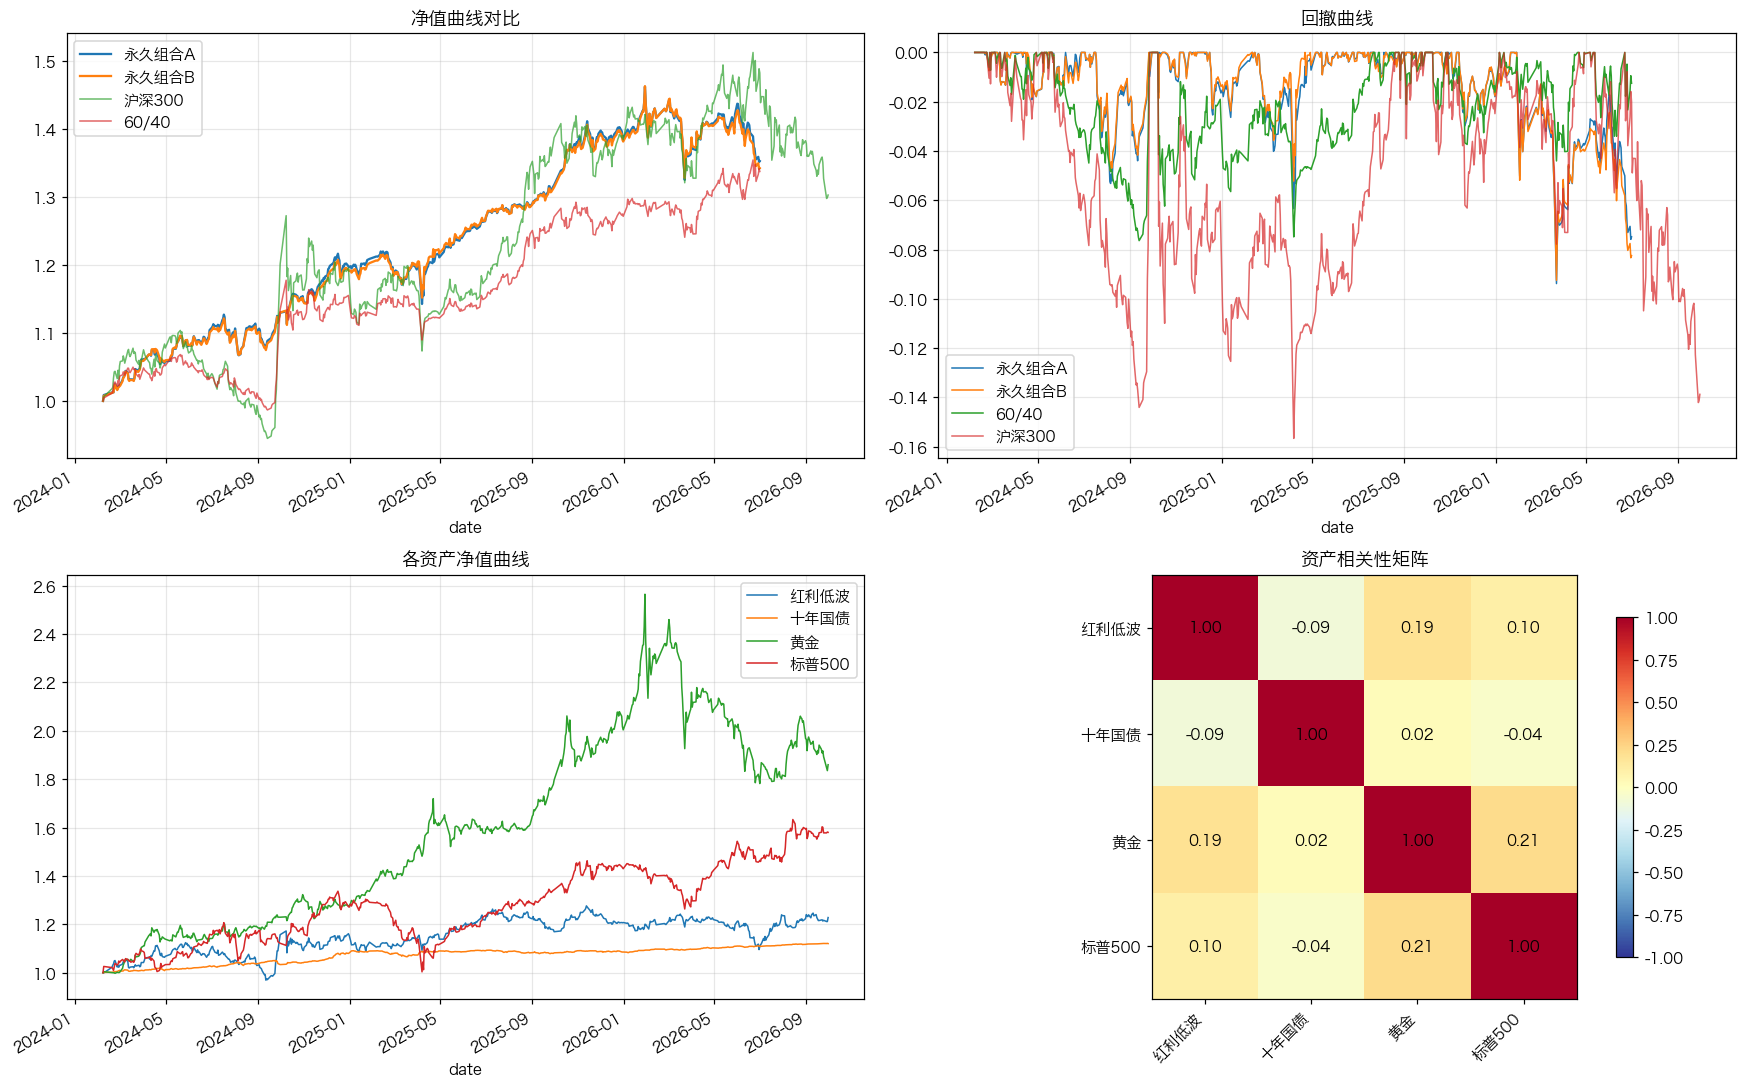

Chart saved to reports/generated/permanent_portfolio_cn.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax = axes[0, 0]
bt_a.daily_nav.plot(ax=ax, label='永久组合A', linewidth=1.5)
bt_b.daily_nav.plot(ax=ax, label='永久组合B', linewidth=1.5)
if bench_300_nav is not None:
    bench_300_nav.plot(ax=ax, label='沪深300', linewidth=1, alpha=0.7)
bt_6040.daily_nav.plot(ax=ax, label='60/40', linewidth=1, alpha=0.7)
ax.set_title('净值曲线对比')
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

ax = axes[0, 1]
for nav_s, label in [(bt_a.daily_nav, '永久组合A'), (bt_b.daily_nav, '永久组合B'),
                      (bt_6040.daily_nav, '60/40')]:
    dd = nav_s / nav_s.expanding().max() - 1
    dd.plot(ax=ax, label=label, linewidth=1)
if bench_300_nav is not None:
    dd300 = bench_300_nav / bench_300_nav.expanding().max() - 1
    dd300.plot(ax=ax, label='沪深300', linewidth=1, alpha=0.7)
ax.set_title('回撤曲线')
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

ax = axes[1, 0]
for code in ['512890', '511260', '518880', '513500']:
    if code in all_data:
        df = all_data[code]
        df = df[(df.index >= BT_START) & (df.index <= BT_END)]
        nav_i = df['close'] / df['close'].iloc[0]
        nav_i.plot(ax=ax, label=ALL_CODES.get(code, code), linewidth=1)
ax.set_title('各资产净值曲线')
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

ax = axes[1, 1]
ret_df = pd.DataFrame()
for code in ['512890', '511260', '518880', '513500']:
    if code in all_data:
        df = all_data[code]
        df = df[(df.index >= BT_START) & (df.index <= BT_END)]
        ret_df[ALL_CODES.get(code, code)] = df['close'].pct_change()
ret_df = ret_df.dropna()
corr = ret_df.corr()
im = ax.imshow(corr.values, cmap='RdYlBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr)))
ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center', fontsize=10)
ax.set_title('资产相关性矩阵')
fig.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
os.makedirs('reports/generated', exist_ok=True)
plt.savefig('reports/generated/permanent_portfolio_cn.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to reports/generated/permanent_portfolio_cn.png')

In [8]:
pos_a = bt_a.quarterly_pos.copy()
pos_a.index = pos_a.index.strftime('%Y-%m-%d')
print('=== 版本 A: 无 QDII 限制 - 季度头寸（万元） ===')
print((pos_a / 10000).round(2).to_string())

print('\n=== 版本 B: QDII 30% 硬顶 - 季度头寸（万元） ===')
pos_b = bt_b.quarterly_pos.copy()
pos_b.index = pos_b.index.strftime('%Y-%m-%d')
print((pos_b / 10000).round(2).to_string())

=== 版本 A: 无 QDII 限制 - 季度头寸（万元） ===
            512890  511260  518880  513500
date                                      
2024-02-07   25.00   25.00   20.00   30.00
2024-04-01   26.52   26.52   21.22   31.83
2024-07-01   27.70   27.70   22.16   33.24
2024-10-08   28.30   28.30   22.64   33.96
2025-01-02   29.96   29.96   23.97   35.96
2025-04-01   30.03   30.03   24.02   36.03
2025-07-01   31.74   31.74   25.39   38.09
2025-10-09   33.48   33.48   26.79   40.18
2026-01-05   34.94   34.94   27.95   41.93
2026-04-01   34.63   34.63   27.70   41.55
2026-07-01   33.83   33.83   27.07   40.60

=== 版本 B: QDII 30% 硬顶 - 季度头寸（万元） ===
            512890  511260  518880  513500
date                                      
2024-02-07   26.79   26.79   21.43   25.00
2024-04-01   28.37   28.37   22.69   26.48
2024-07-01   29.58   29.58   23.67   27.61
2024-10-08   30.35   30.35   24.28   28.33
2025-01-02   31.93   31.93   25.55   29.80
2025-04-01   32.26   32.26   25.81   30.11
2025-07-01   34.04   34.

In [9]:
def monthly_returns(nav):
    ret = nav.pct_change().dropna()
    ret.index = pd.to_datetime(ret.index)
    monthly = ret.resample('M').apply(lambda x: (1+x).prod()-1)
    table = pd.DataFrame({
        'year': monthly.index.year,
        'month': monthly.index.month,
        'return': monthly.values
    })
    pivot = table.pivot(index='year', columns='month', values='return')
    pivot.columns = [f'{m}月' for m in pivot.columns]
    return pivot

print('=== 永久组合A 月度收益 ===')
mr_a = monthly_returns(bt_a.daily_nav)
print((mr_a * 100).round(2).to_string())

print('\n=== 永久组合B 月度收益 ===')
mr_b = monthly_returns(bt_b.daily_nav)
print((mr_b * 100).round(2).to_string())

if bench_300_nav is not None:
    print('\n=== 沪深300 月度收益 ===')
    mr_300 = monthly_returns(bench_300_nav)
    print((mr_300 * 100).round(2).to_string())

=== 永久组合A 月度收益 ===
        1月    2月    3月    4月    5月    6月    7月    8月    9月   10月   11月   12月
year                                                                        
2024   NaN  2.29  3.74 -0.28  2.24  2.08 -0.38  0.25  2.44  1.60  3.08  1.15
2025  1.03 -1.95  0.67  1.50  2.34  2.00  1.35  0.42  2.40  4.71  0.98 -0.50
2026  3.75 -0.65 -4.60  3.29  0.99 -4.96  0.11   NaN   NaN   NaN   NaN   NaN

=== 永久组合B 月度收益 ===
        1月    2月    3月    4月    5月    6月    7月    8月    9月   10月   11月   12月
year                                                                        
2024   NaN  2.15  3.67  0.08  2.21  1.60 -0.32  0.16  2.87  1.38  2.61  1.32
2025  0.98 -1.56  1.12  1.64  2.12  1.80  1.11  0.47  2.28  4.51  1.03 -0.44
2026  4.00 -0.55 -4.28  2.71  0.63 -5.12  0.09   NaN   NaN   NaN   NaN   NaN

=== 沪深300 月度收益 ===
        1月    2月    3月    4月    5月    6月    7月     8月     9月   10月   11月   12月
year                                                                          
2024   NaN  5